In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [2]:
import yfinance as yf

# 1. Fetch data explicitly turning off auto-adjustment to preserve 'Adj Close'
df = yf.download("NGE", start="2021-01-01", end="2026-01-01", auto_adjust=False)

# 2. Senior Dev Move: Flatten yfinance's new multi-index headers down to simple strings
df.columns = [col[0] for col in df.columns]

# 3. Safely isolate the column and forward-fill missing dates
df = df[['Adj Close']].ffill()

# View the clean pipeline output
print("[SUCCESS] Data cleanly loaded into the pipeline!")
print(df.tail())


[*********************100%***********************]  1 of 1 completed

[SUCCESS] Data cleanly loaded into the pipeline!
            Adj Close
Date                 
2024-03-22       3.74
2024-03-25       3.74
2024-03-26       3.74
2024-03-27       3.74
2024-03-28       3.74


In [3]:
# import yfinance as yf

# # Pull Zenith Bank via its London Stock Exchange global listing
# df = yf.download("0QVM.L", start="2021-01-01", end="2026-01-01", auto_adjust=False)

# # Flatten columns to remove multi-index errors
# df.columns = [col for col in df.columns]

# # Isolate Adjusted Close and fill gaps
# df = df[['Adj Close']].ffill()

# print("[SUCCESS] Living market data retrieved!")
# print("Dataframe Shape:", df.shape)
# print(df.dropna().tail())


In [4]:
# df.to_csv("Stock Analysis.csv")

In [5]:
import yfinance as yf
import pandas as pd

print("[INFO] Initializing stable data pipeline extraction...")

# 1. Download data with auto_adjust=False to preserve raw asset metrics
raw_df = yf.download("AAPL", start="2021-01-01", end="2026-01-01", auto_adjust=False)

# 2. Extract column headers cleanly (handles both Multi-Index and Flat index structures)
if isinstance(raw_df.columns, pd.MultiIndex):
    # Take just the metric name (e.g., 'Adj Close') and discard the ticker level
    raw_df.columns = [col[0] for col in raw_df.columns]
else:
    raw_df.columns = [str(col) for col in raw_df.columns]

# 3. Dynamic Column Fallback: Locate adjusted close, or fallback to standard close if missing
df = pd.DataFrame(index=raw_df.index)
if 'Adj Close' in raw_df.columns:
    df['Adj Close'] = raw_df['Adj Close']
elif 'Close' in raw_df.columns:
    print("[WARNING] 'Adj Close' not found. Falling back to standard 'Close'.")
    df['Adj Close'] = raw_df['Close']
else:
    raise KeyError(f"Could not locate price data. Available columns: {list(raw_df.columns)}")

# 4. Forward fill missing market data gaps (weekends/holidays)
df = df.ffill()

print("\n[SUCCESS] Living market data cleanly loaded into your pipeline!")
print(f"Dataframe Dimensions: {df.shape[0]} trading rows across {df.shape[1]} column.")
print("\n--- Validation Sample (Tail End) ---")
print(df.tail())


[INFO] Initializing stable data pipeline extraction...


[*********************100%***********************]  1 of 1 completed


[SUCCESS] Living market data cleanly loaded into your pipeline!
Dataframe Dimensions: 1255 trading rows across 1 column.

--- Validation Sample (Tail End) ---
             Adj Close
Date                  
2025-12-24  273.302216
2025-12-26  272.892975
2025-12-29  273.252350
2025-12-30  272.573578
2025-12-31  271.355835


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

print("[INFO] Starting Day 2 Statistical Analysis Pipeline...")

# 1. Run the Augmented Dickey-Fuller (ADF) Test on Raw Prices
print("\n--- Running ADF Test on Raw Prices ---")
result_raw = adfuller(df['Adj Close'])
print(f"ADF Statistic: {result_raw[0]:.4f}")
print(f"p-value: {result_raw[1]:.4f}")

# Interpret the p-value
if result_raw[1] <= 0.05:
    print("[RESULT] The raw price data is STATIONARY (p <= 0.05). No differencing needed.")
else:
    print("[RESULT] The raw price data is NON-STATIONARY (p > 0.05). Differencing required.")

# 2. Senior Dev Move: Calculate Log Returns and First Differences
print("\n--- Applying First Differencing (Stationary Transformation) ---")
df['Price_Diff'] = df['Adj Close'].diff()
df['Log_Return'] = df['Adj Close'].pct_change()

# Drop the resulting NaN in row 1 from differencing to prevent statistical crashes
df_clean = df.dropna()

# 3. Re-run the ADF Test on the Differenced Data to confirm success
result_diff = adfuller(df_clean['Price_Diff'])
print(f"Differenced ADF Statistic: {result_diff[0]:.4f}")
print(f"Differenced p-value: {result_diff[1]:.4f}")

if result_diff[1] <= 0.05:
    print("[SUCCESS] Differenced data is perfectly STATIONARY! Ready for modeling.")
else:
    print("[WARNING] Data still non-stationary. Higher-order differencing may be required.")


[INFO] Starting Day 2 Statistical Analysis Pipeline...

--- Running ADF Test on Raw Prices ---
ADF Statistic: -0.7873
p-value: 0.8228
[RESULT] The raw price data is NON-STATIONARY (p > 0.05). Differencing required.

--- Applying First Differencing (Stationary Transformation) ---
Differenced ADF Statistic: -33.8260
Differenced p-value: 0.0000
[SUCCESS] Differenced data is perfectly STATIONARY! Ready for modeling.


In [7]:
df_clean

,Adj Close,Price_Diff,Log_Return
Date,,,
2021-01-05,127.295525,1.554634,0.012364
2021-01-06,123.010536,-4.284988,-0.033662
2021-01-07,127.208023,4.197487,0.034123
2021-01-08,128.306030,1.098007,0.008632
2021-01-11,125.323036,-2.982994,-0.023249
...,...,...,...
2025-12-24,273.302216,1.447296,0.005324
2025-12-26,272.892975,-0.409241,-0.001497
2025-12-29,273.252350,0.359375,0.001317


[INFO] Computing ACF and PACF plots on Stationary Data...
[SUCCESS] Plots generated successfully. Look at your notebook figure output.


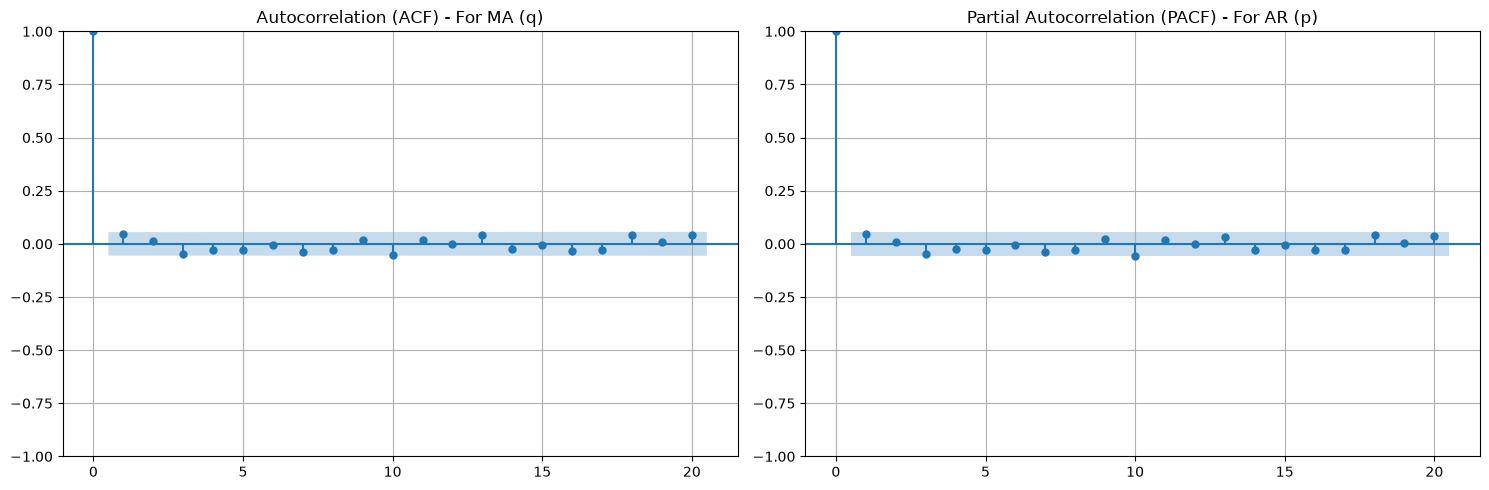

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

print("[INFO] Computing ACF and PACF plots on Stationary Data...")

# Isolate clean stationary differences
stationary_series = df['Price_Diff'].dropna()

# Create a clean side-by-side plot layout
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot Autocorrelation Function (ACF) to determine potential 'q' values
sm.graphics.tsa.plot_acf(stationary_series, lags=20, ax=axes[0])
axes[0].set_title('Autocorrelation (ACF) - For MA (q)')
axes[0].grid(True)

# Plot Partial Autocorrelation Function (PACF) to determine potential 'p' values
sm.graphics.tsa.plot_pacf(stationary_series, lags=20, ax=axes[1], method='ywm')
axes[1].set_title('Partial Autocorrelation (PACF) - For AR (p)')
axes[1].grid(True)

plt.tight_layout()
print("[SUCCESS] Plots generated successfully. Look at your notebook figure output.")
